# PPO结构代码

[PPO数学原理和代码详解](https://walkinglabs.github.io/hands-on-modern-rl/chapter10_ppo/ppo-math#%E9%87%8D%E8%A6%81%E6%80%A7%E9%87%87%E6%A0%B7)

导入必要的包

In [8]:
import numpy as np
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Categorical

1. backbone用来提取通用的特征
2. forward函数用来把每个动作的概率输出，value是Critic网络预测的状态价值
3. act函数主要是用来选择动作，并且获取这个动作的概率
4. evaluate主要是计算loss的时候使用，他用新参数网络来计算旧动作的分布，方便后面做重要性采样

## 什么是重要性采样？

重要性采样（Importance Sampling）想要解决的核心问题是：如何合法地“废物利用”——让新策略能够使用旧策略采到的数据进行多次参数更新，从而解决原始策略梯度“样本利用率极低（Sample Inefficiency）”的问题。

PPO 算法中的重要性采样 (Importance Sampling)

 🎯 痛点
每次更新都需要新数据，导致**样本利用率极低**。

 🏢 场景
为了提高效率，在 PPO 等算法中，同一批 rollout 数据会被放入网络中反复迭代多轮（比如 4 轮或 10 轮）。

⚠️ 问题
每一轮迭代后，ctor 网络的参数 $\theta$ 变了，策略更新了。如果不做处理，拿着旧分布的数据去算新分布的梯度，方向就会跑偏。

💡 解法
引入**重要性权重 (Importance Weight)** 进行修正：

$$
\text{Weight} = \frac{\pi_{\text{old}}(a_t \mid s_t)}{\pi_{\text{new}}(a_t \mid s_t)}
$$

下面的act 和 evaluate 分别是在旧策略和新策略下的log_prob, 用于后面放入到重要性采样里面

代理目标surr1：下面的ratio * advantages 就是 raito比例*advantages(优势)，算出来的就是根据来决策上算出来的优势，然后新旧策略比值 * 优势得到新策略上的优势


用策略比率ratio把旧数据的分布"翻译"成新策略的分布，让 J(θ) 的梯度可以用旧数据来估计。

In [ ]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
        )
        self.actor_head = nn.Linear(hidden, act_dim)
        self.critic_head = nn.Linear(hidden, 1)
 
    # [A] 策略和值函数：Actor 输出动作概率，Critic 输出状态价值
    def forward(self, obs):
        h = self.backbone(obs) 
        logits = self.actor_head(h)
        action_probs = F.softmax(logits, dim=-1) 
        value = self.critic_head(h).squeeze(-1)
        return action_probs, value
 
    # [B] 动作采样：根据策略分布选择动作，并记录 log_prob
    def act(self, obs):
        action_probs, value = self.forward(obs)
        dist = Categorical(action_probs)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        return action, log_prob, value
 
    def evaluate(self, obs, actions):
        action_probs, values = self.forward(obs) # 1. 用最新的网络参数重新前向传播
        dist = Categorical(action_probs)# 2. 用最新参数构建新的概率分布
        new_logprobs = dist.log_prob(actions) # 3. 核心：评估历史动作在新分布下的概率
        entropy = dist.entropy()
        return new_logprobs, values, entropy

收集数据，这些数据都是来自旧策略，用于后面更新Actor网络，然后这里需要收集action(用于重要性采样)，old_logprob(用于重要性采样)，value（用来计算TD error 和 Critic网络逼近） 

In [ ]:
# [C] 采样一批 on-policy 数据：这些数据来自旧策略
def collect_rollout(env, model, steps=2048, device="cpu"):
    obs, _ = env.reset()
    batch = {k: [] for k in ["states", "actions", "rewards", "dones", "old_logprobs", "values"]}
 
    for _ in range(steps):
        obs_tensor = torch.as_tensor(obs, dtype=torch.float32, device=device)
        with torch.no_grad():
            action, old_logprob, value = model.act(obs_tensor)
 
        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated
 
        batch["states"].append(obs)
        batch["actions"].append(action.item())
        batch["rewards"].append(reward)
        batch["dones"].append(done)
        batch["old_logprobs"].append(old_logprob.item())
        batch["values"].append(value.item())
 
        obs = next_obs if not done else env.reset()[0]
 
    return {
        "states": torch.as_tensor(np.array(batch["states"]), dtype=torch.float32, device=device),
        "actions": torch.as_tensor(batch["actions"], dtype=torch.long, device=device),
        "rewards": torch.as_tensor(batch["rewards"], dtype=torch.float32, device=device),
        "dones": torch.as_tensor(batch["dones"], dtype=torch.float32, device=device),
        "old_logprobs": torch.as_tensor(batch["old_logprobs"], dtype=torch.float32, device=device),
        "values": torch.as_tensor(batch["values"], dtype=torch.float32, device=device),
    }

1. TD eroor : reward + gamma（折旧权重，表示未来的）* next_value(下一个状态的Critic预测) * done - values[t]\(当前状态的Crtiic预测)
2. last_advantage(GAE) : 它就是把整条链路的一个 TDL 给加在一起，然后算出来它在完整访问的一条线路里面所具有的全部误差。
   1. 当 lambda 为 0 时，它会退化为 TD0，只看当前这一步的真实奖励reward，剩下的全靠 Critic 网络猜。因为只走了一步，环境带来的随机性小（低方差）；但如果 Critic 猜得很离谱，误差就会很大（高偏差）。
   2. 当 λ 为 1 的时候，它就会退化成 MC，绝对信任环境给出的真实反馈(reward全部相加)，不依赖 Critic 对**未来状态**的猜测（无偏差）；但因为要等整条轨迹跑完，中间包含了太多的环境随机性（高方差）。

In [ ]:
# [D] 计算优势：GAE（Generalized Advantage Estimation）
def compute_gae(rewards, values, dones, gamma=0.99, lam=0.95):
    advantages = torch.zeros_like(rewards)
    last_advantage = 0.0
    next_value = 0.0
 
    for t in reversed(range(len(rewards))):
        mask = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_value * mask - values[t]
        last_advantage = delta + gamma * lam * mask * last_advantage # lam = 0的时候，GAE退化为TD(0)，说明不相信Critic网络的长期预测 ；lam = 1的时候，GAE退化为Monte Carlo
        advantages[t] = last_advantage # 用于后面快速计算每个步骤的TD误差
        next_value = values[t]
 
    returns = advantages + values
    advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
    return advantages, returns

actor_loss_fn（策略损失）：surr1使用了重要性采样， surr2使用了重要性采样 + 信任域更新（性质变化），两者取最小值，即每次希望更新的幅度不要太大（所以取min）

critic_loss_fn（价值损失） ： Critic 的期望是让目标函数越小越好，因此为了保守更新，我们这里取一个 Max，以让 Critic 网络在一次更新中不要更新过大。


In [1]:
# [E] PPO 损失函数（DeepSpeed-Chat / VeRL / OpenRLHF 风格）
def actor_loss_fn(new_logprobs, old_logprobs, advantages, clip_eps=0.2):
    ratio = torch.exp(new_logprobs - old_logprobs)
    surr1 = ratio * advantages
    surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * advantages
    policy_loss = -torch.min(surr1, surr2).mean()
    return policy_loss

def critic_loss_fn(new_values, old_values, returns, clip_eps_value=0.2):
    values_clipped = torch.clamp(
        new_values, old_values - clip_eps_value, old_values + clip_eps_value
    )
    vf_loss1 = (new_values - returns) ** 2
    vf_loss2 = (values_clipped - returns) ** 2
    vf_loss = 0.5 * torch.max(vf_loss1, vf_loss2).mean()
    return vf_loss

In [2]:
def ppo_update(model, optimizer, batch, advantages, returns,
               clip_eps=0.2, vf_coef=0.5, ent_coef=0.01,
               epochs=10, minibatch_size=64):
    states = batch["states"]
    actions = batch["actions"]
    old_logprobs = batch["old_logprobs"]
    old_values = batch["values"]
    batch_size = states.size(0)
 
    for _ in range(epochs):
        indices = torch.randperm(batch_size, device=states.device)
        for start in range(0, batch_size, minibatch_size):
            mb = indices[start:start + minibatch_size]
 
            new_logprobs, new_values, entropy = model.evaluate(states[mb], actions[mb])
 
            pg_loss = actor_loss_fn(new_logprobs, old_logprobs[mb], advantages[mb], clip_eps)
            vf_loss = critic_loss_fn(new_values, old_values[mb], returns[mb], clip_eps)
            entropy_bonus = entropy.mean()
            loss = pg_loss + vf_coef * vf_loss - ent_coef * entropy_bonus
 
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
 
 
# [F] 训练循环：采样一批数据，再用这批数据更新多轮
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
env = gym.make("CartPole-v1")
model = ActorCritic(env.observation_space.shape[0], env.action_space.n).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
 
for update in range(100):
    batch = collect_rollout(env, model, steps=2048, device=device)
    advantages, returns = compute_gae(batch["rewards"], batch["values"], batch["dones"])
    ppo_update(model, optimizer, batch, advantages, returns)

NameError: name 'torch' is not defined

PPO 的每次更新要么停止，要么沿优势指示的正确方向进行——永远不会反向，也永远不会在需要纠偏时卡死。

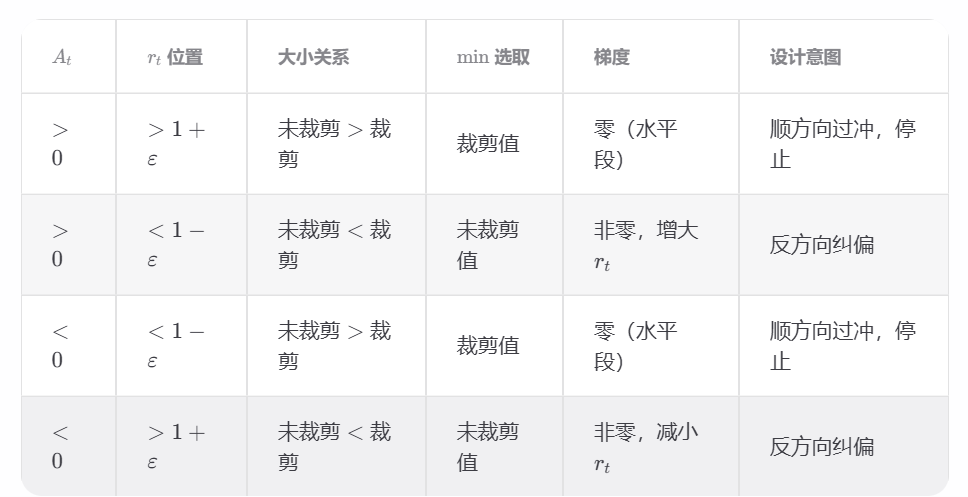

逐一确定 $L$ 等于哪一项：

- $r_t \in [1-\varepsilon, 1+\varepsilon]$: $c=r_t$，两项相等，$L = r_t A_t$，$\frac{\partial L}{\partial r_t} = A_t$。

- $r_t > 1+\varepsilon$: $c=1+\varepsilon$ 为常数。

  - $A_t > 0$: $r_t A_t > (1+\varepsilon) A_t$，min 选裁剪项（常数），$\frac{\partial L}{\partial r_t} = 0$。(A_t > 0 说明是好动作，但是r_t > 0, 说明决策网络倾向于增大好动作决策，为了不夸张更新，因此剪裁不更新)

  - $A_t < 0$: 两边乘负数翻转不等号，$r_t A_t < (1+\varepsilon) A_t$，min 选未裁剪项，$\frac{\partial L}{\partial r_t} = A_t$。(A_t < 0 说明是坏动作，但是r_t > 0, 说明决策网络倾向于增大坏动作决策，为了纠正，不剪裁，求出来的梯度是A_t < 0, 此时说明后续通过这次更新可以把r_t 减少回去， 也就是把当前坏动作的倾向抑制回去)


- $r_t < 1-\varepsilon$: $c=1-\varepsilon$ 为常数。（分析同上）

  - $A_t > 0$: $r_t A_t < (1-\varepsilon) A_t$，min 选未裁剪项，$\frac{\partial L}{\partial r_t} = A_t$。

  - $A_t < 0$: 翻转后 $r_t A_t > (1-\varepsilon) A_t$，min 选裁剪项（常数），$\frac{\partial L}{\partial r_t} = 0$。

# $\varepsilon$ 的敏感性

$\varepsilon$ 的选择直接影响训练效果，以下为经验性总结：

| $\varepsilon$ 值 | 更新幅度 | 训练速度 | 稳定性 | 适用场景 | 
| ----- | ----- | ----- | ----- | ----- | 
| 0.05 | 很小 | 很慢 | 极其稳定 | 精调已训练好的策略 | 
| 0.1 | 较小 | 较慢 | 稳定 | LLM 对齐（参数多，更脆弱） | 
| 0.2 | 中等 | 适中 | 适中 | 游戏/控制任务（默认值） | 
| 0.3 | 较大 | 较快 | 不稳定 | 快速实验/简单任务 | 
| 0.5 | 很大 | 快但容易崩 | 很不稳定 | 不推荐 |

# lambda的意义

**Critic 完全随机时，GAE 在不同 \(\lambda\) 下的退化**

GAE 的定义为：

$$
\hat A_t^{\mathrm{GAE}}
=\sum_{k=0}^{\infty}(\gamma\lambda)^k\delta_{t+k},
$$

其中一步 TD 误差为：

$$
\delta_t
=r_t+\gamma V(s_{t+1})-V(s_t).
$$

假设 Critic 完全没有学习到有效信息，\(V(s)\) 的输出可以近似看成随机噪声。此时，\(\lambda\) 的不同取值会让 GAE 退化成不同形式。

---

**当 \(\lambda=0\) 时**

GAE 只保留当前的一步 TD 误差：

$$
\hat A_t
=\delta_t
=r_t+\gamma V(s_{t+1})-V(s_t).
$$

由于 Critic 是随机的，\(V(s_t)\) 和 \(V(s_{t+1})\) 都是噪声，因此：

$$
\gamma V(s_{t+1})-V(s_t)
$$

也会成为随机噪声。

此时优势估计只有即时奖励 \(r_t\) 可能包含真实信号，而未来奖励的信息完全依赖随机 Critic 提供的 bootstrap。因此：

- 如果奖励稀疏或延迟，\(\delta_t\) 中几乎没有有效的长期信用分配信息；
- 如果 Critic 噪声远大于即时奖励，真实奖励信号也会被淹没；
- 一步 TD 的优势估计会变得非常不可靠。

因此，\(\lambda=0\) 相当于将未来回报估计几乎完全交给 Critic。Critic 一旦失效，优势估计也会严重失效。

> 更准确地说，\(\delta_t\) 并非必然“完全没有意义”，因为其中仍然包含真实的即时奖励 \(r_t\)。但在奖励稀疏、延迟或者 Critic 噪声较大的任务中，它通常很难提供有效信号。

---

**当 \(\lambda=1\) 时**

此时：

$$
\hat A_t
=\sum_{k=0}^{\infty}\gamma^k\delta_{t+k}.
$$

对于完整轨迹，中间状态的价值项会通过望远镜求和相互抵消，因此：

$$
\hat A_t
=G_t-V(s_t).
$$

其中：

$$
G_t
=r_t+\gamma r_{t+1}+\gamma^2r_{t+2}+\cdots
$$

是从环境中实际采样得到的蒙特卡洛回报。

即使 Critic 是随机的，\(G_t\) 仍然保留了真实的累计奖励信号。随机 Critic 只以 baseline 的形式出现在：

$$
-V(s_t).
$$

因此，\(\lambda=1\) 时，GAE 会退化为：

$$
\boxed{\text{带随机 baseline 的 MC 优势估计}}
$$

如果 \(V(s_t)\) 只依赖状态、不依赖当前动作，并且在计算策略梯度时停止对它反向传播，那么减去这个 baseline 通常不会改变策略梯度的期望：

$$
\mathbb E_{a_t\sim\pi}
\left[
\nabla_\theta\log\pi_\theta(a_t\mid s_t)V(s_t)
\right]
=0.
$$

但随机的 \(V(s_t)\) 并不是完全无关紧要，它仍然可能显著增加优势估计的方差。只有当它的噪声相对于 \(G_t\) 较小时，主体的 MC 信号才会明显占主导。

---

**两种情况的比较**

| \(\lambda\) | 退化形式 | Critic 随机时的主要问题 | 可用性 |
|---:|---|---|---|
| \(0\) | \(r_t+\gamma V(s_{t+1})-V(s_t)\) | 当前和下一状态的随机价值噪声直接进入 TD 目标 | 通常较差 |
| \(1\) | \(G_t-V(s_t)\) | MC 回报仍然真实，但随机 baseline 会增加方差 | 通常更可用 |

所以，在 Critic 完全失效的情况下：

$$
\boxed{\lambda=1\text{ 通常比 }\lambda=0\text{ 更鲁棒}}
$$

原因不是随机 \(V(s_t)\) 完全没有影响，而是 \(\lambda=1\) 保留了完整的真实回报 \(G_t\)，不再依赖随机 Critic 估计远期奖励。

---

**为什么工程中常用 \(\lambda=0.95\)？**

增大 \(\lambda\) 可以减少对 Critic bootstrap 的依赖，使优势估计更接近真实的蒙特卡洛回报；但代价是会引入更多由轨迹采样造成的方差。

可以将 \(\lambda\) 的选择理解为在下面两个因素之间折中：

$$
\boxed{
\text{Critic 估计误差}
\quad\longleftrightarrow\quad
\text{蒙特卡洛采样方差}
}
$$

- \(\lambda\) 较小：更依赖 Critic，方差通常较低，但 Critic 不准确时偏差和误差更明显；
- \(\lambda\) 较大：更依赖真实轨迹回报，对 Critic 误差更鲁棒，但采样方差更大；
- \(\lambda=0.95\)：在许多任务中能取得较实用的偏差—方差折中，因此经常作为默认起点。

不过，\(0.95\) 并不是所有任务的理论最优值。合理的 \(\lambda\) 还会受到奖励稀疏程度、轨迹长度、折扣因子、Critic 质量和样本数量等因素影响。

---

**核心结论**

- Critic 完全随机时，\(\lambda=0\) 退化为带有两个随机价值项的一步 TD；
- Critic 完全随机时，\(\lambda=1\) 退化为带随机 baseline 的 MC；
- \(\lambda=1\) 保留了真实累计回报，因此通常比 \(\lambda=0\) 更可用；
- 随机 baseline 仍可能增加方差，不能将它简单视为毫无影响的常数；
- 较大的 \(\lambda\) 通常更不依赖 Critic，但会付出更高采样方差的代价；
- \(\lambda=0.95\) 是常用的经验折中，而不是普遍成立的最优解。

